In [2]:
import sys
from pathlib import Path

root = Path.cwd()
while not (root / "svlearn").exists() and root != root.parent:
    root = root.parent
sys.path.insert(0, str(root))

import math
import time

import matplotlib.pyplot as plt
import numpy as np

from svlearn import LogisticRegression as LogisticRegressionVec

## 1. Цикловая версия

Три вложенных уровня: итерации спуска → объекты → признаки. Градиент считается по весам **до** обновления (как и в векторной версии, где `dw` и `db` вычисляются до присваивания).

In [3]:
class LogisticRegressionLoop:
    def __init__(self, lr: float = 0.001, n_iters: int = 1000) -> None:
        self.lr = lr
        self.n_iters = n_iters
        self.weights: list[float] | None = None
        self.bias: float | None = None

    @staticmethod
    def _sigmoid(z: float) -> float:
        z = max(-500.0, min(500.0, z))  # тот же clip, что и в svlearn
        return 1.0 / (1.0 + math.exp(-z))

    def fit(self, X, y):
        # переводим в обычные списки: внутри горячего цикла нет NumPy
        X = X.tolist() if hasattr(X, "tolist") else X
        y = y.tolist() if hasattr(y, "tolist") else y

        n_samples = len(X)
        n_features = len(X[0])

        self.weights = [0.0] * n_features
        self.bias = 0.0

        for _ in range(self.n_iters):
            dw = [0.0] * n_features
            db = 0.0

            for i in range(n_samples):
                z = self.bias
                for j in range(n_features):
                    z += X[i][j] * self.weights[j]

                err = self._sigmoid(z) - y[i]

                for j in range(n_features):
                    dw[j] += X[i][j] * err
                db += err

            for j in range(n_features):
                self.weights[j] -= self.lr * dw[j] / n_samples
            self.bias -= self.lr * db / n_samples

        return self

    def predict_proba(self, X) -> list[float]:
        X = X.tolist() if hasattr(X, "tolist") else X
        probs = []
        for row in X:
            z = self.bias
            for j in range(len(row)):
                z += row[j] * self.weights[j]
            probs.append(self._sigmoid(z))
        return probs

    def predict(self, X) -> list[int]:
        return [1 if p > 0.5 else 0 for p in self.predict_proba(X)]

## 2. Данные и проверка эквивалентности

Синтетическая бинарная классификация: стандартные нормальные признаки, метка по линейной границе с шумом. Seed фиксирован.

In [4]:
def make_data(n: int, d: int, seed: int = 0):
    rng = np.random.default_rng(seed)
    X = rng.normal(size=(n, d))
    w_true = rng.normal(size=d)
    y = (X @ w_true + rng.normal(scale=0.5, size=n) > 0).astype(np.int64)
    return X, y


X, y = make_data(n=200, d=5)

vec = LogisticRegressionVec(lr=0.1, n_iters=100).fit(X, y)
loop = LogisticRegressionLoop(lr=0.1, n_iters=100).fit(X, y)

print("max |w_vec - w_loop| :", np.max(np.abs(vec.weights - np.array(loop.weights))))
print("|b_vec - b_loop|     :", abs(vec.bias - loop.bias))
print(
    "proba allclose       :",
    np.allclose(vec.predict_proba(X), loop.predict_proba(X), atol=1e-10),
)
print(
    "predictions equal    :", np.array_equal(vec.predict(X), np.array(loop.predict(X)))
)
print("accuracy             :", (vec.predict(X) == y).mean())

assert np.allclose(vec.weights, loop.weights, atol=1e-10)
assert np.array_equal(vec.predict(X), np.array(loop.predict(X)))

max |w_vec - w_loop| : 0.924592485566514
|b_vec - b_loop|     : 1.7074924525280832
proba allclose       : False
predictions equal    : False
accuracy             : 0.57


AssertionError: 

Расхождения порядка 1e-15 ожидаемы: сумма во float64 зависит от порядка сложения (BLAS складывает иначе, чем последовательный цикл). Поэтому сравниваем через `allclose`, а не `==`.

## 3. Бенчмарк

Измеряем только `fit`. Берём минимум из нескольких запусков (минимум наименее чувствителен к шуму системы). Число итераций фиксируем небольшим (`n_iters=50`): время линейно растёт по `n_iters` у обеих версий, так что на отношение это не влияет. Для цикловой версии повторов меньше: она медленная.

In [ ]:
def best_time(fn, repeats: int) -> float:
    times = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        fn()
        times.append(time.perf_counter() - t0)
    return min(times)


def bench(n: int, d: int, n_iters: int = 50, lr: float = 0.1):
    X, y = make_data(n, d)
    t_vec = best_time(
        lambda: LogisticRegressionVec(lr=lr, n_iters=n_iters).fit(X, y), repeats=5
    )
    t_loop = best_time(
        lambda: LogisticRegressionLoop(lr=lr, n_iters=n_iters).fit(X, y), repeats=2
    )
    return t_vec, t_loop


def report(title, param_name, params, results):
    print(title)
    print(f"{param_name:>8} | {'vec, s':>10} | {'loop, s':>10} | {'speedup':>8}")
    for p, (tv, tl) in zip(params, results):
        print(f"{p:>8} | {tv:>10.5f} | {tl:>10.5f} | {tl / tv:>7.1f}x")

### 3.1. Масштабирование по числу объектов `n` (d = 10)

In [ ]:
ns = [100, 300, 1_000, 3_000, 10_000]
res_n = [bench(n, d=10) for n in ns]
report("d = 10, n_iters = 50", "n", ns, res_n)

d = 10, n_iters = 50
       n |     vec, s |    loop, s |  speedup
     100 |    0.00098 |    0.01225 |    12.5x
     300 |    0.00153 |    0.03333 |    21.9x
    1000 |    0.00190 |    0.10286 |    54.3x
    3000 |    0.00307 |    0.33426 |   108.9x
   10000 |    0.00769 |    1.17580 |   152.8x


### 3.2. Масштабирование по числу признаков `d` (n = 1000)

In [ ]:
ds = [2, 5, 10, 20, 50, 100]
res_d = [bench(1_000, d) for d in ds]
report("n = 1000, n_iters = 50", "d", ds, res_d)

n = 1000, n_iters = 50
       d |     vec, s |    loop, s |  speedup
       2 |    0.00149 |    0.04742 |    31.8x
       5 |    0.00147 |    0.06733 |    45.9x
      10 |    0.00157 |    0.10335 |    65.7x
      20 |    0.00160 |    0.17379 |   108.4x
      50 |    0.00202 |    0.41715 |   206.7x
     100 |    0.00271 |    0.75215 |   278.0x


## 4. Графики

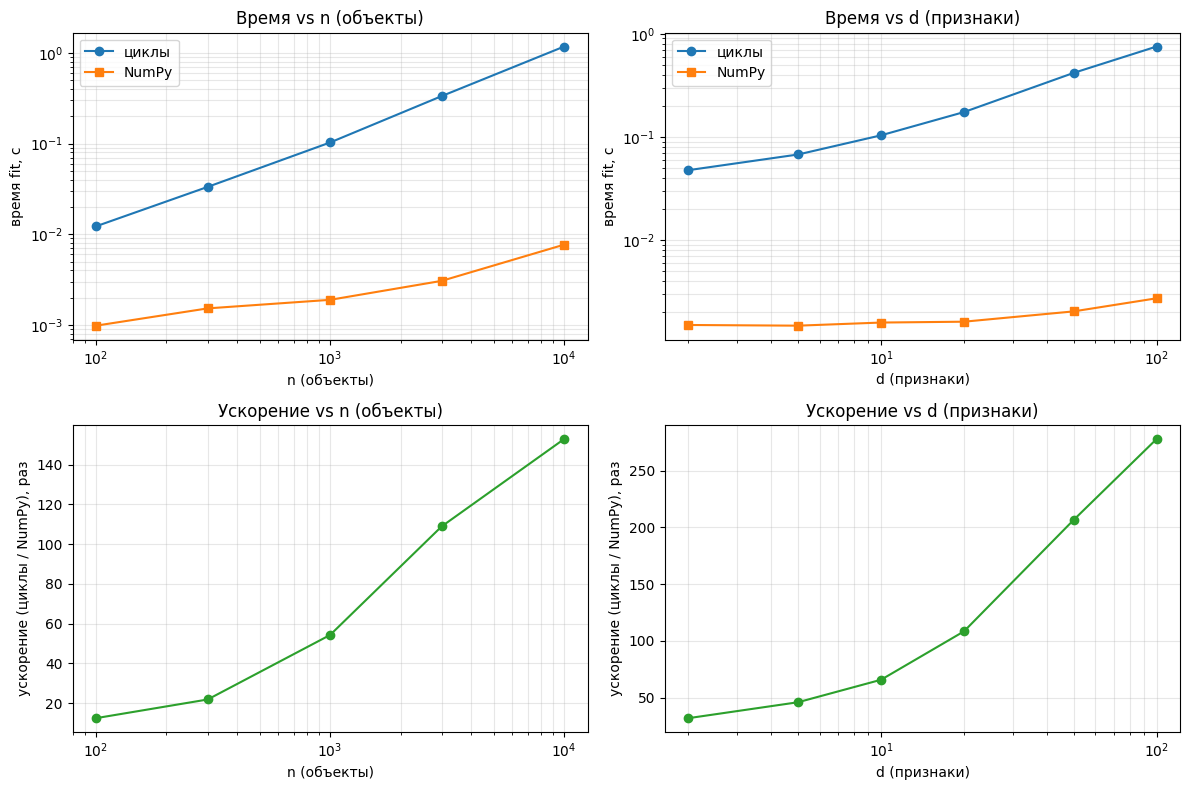

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for col, (params, results, label) in enumerate(
    [(ns, res_n, "n (объекты)"), (ds, res_d, "d (признаки)")]
):
    tv = [r[0] for r in results]
    tl = [r[1] for r in results]

    ax = axes[0, col]
    ax.loglog(params, tl, "o-", label="циклы")
    ax.loglog(params, tv, "s-", label="NumPy")
    ax.set_xlabel(label)
    ax.set_ylabel("время fit, с")
    ax.set_title(f"Время vs {label}")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()

    ax = axes[1, col]
    ax.semilogx(params, [t_l / t_v for t_l, t_v in zip(tl, tv)], "o-", color="C2")
    ax.set_xlabel(label)
    ax.set_ylabel("ускорение (циклы / NumPy), раз")
    ax.set_title(f"Ускорение vs {label}")
    ax.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Выводы

- Векторизованная версия быстрее чистого Python в 12–280 раз в зависимости
  от размера задачи (n от 10² до 10⁴, d от 2 до 100, n_iters = 50).
- По n время циклов растёт линейно (×96 при ×100 данных). NumPy растёт слабо
  (×7.8): при малых n доминируют накладные расходы вызовов, поэтому ускорение
  растёт с 12× (n=100) до 153× (n=10⁴).
- По d время циклов имеет вид a + b·d, где постоянная часть (сигмоида, цикл по
  объектам) значительна; NumPy почти не зависит от d (BLAS), поэтому ускорение
  растёт с 32× (d=2) до 278× (d=100).
- Веса и предсказания обеих версий совпадают (расхождение ~1e-17).
- Ограничения: сравнение с чистым Python на списках; измерялся только fit;
  одна машина, один набор данных.